# AI 면접관 — QLoRA 4bit

이 노트북은 기존 `test.py`를 기준으로 다음 문제를 막도록 정리한 개선판입니다.

1. **LoRA adapter가 붙었지만 trainable이 0개가 되는 문제**를 `ensure_lora_trainable()`로 강제 점검합니다.
2. `prompt` / `completion` 컬럼만 `SFTTrainer`에 넘겨서 데이터 포맷 해석을 명확하게 합니다.
3. `completion_only_loss=True`가 실제로 completion 토큰에만 걸리는지 확인하는 진단 셀을 넣었습니다.
4. 작은 데이터셋에서 loss가 출렁이는 문제를 고려해 `max_steps`, `logging_steps`, `warmup_ratio`, `max_grad_norm`을 안정적으로 조정했습니다.
5. Qwen 계열 chat template의 EOS 토큰이 `<|im_end|>`인지 확인하고 `SFTConfig(eos_token=...)`에 명시합니다.

> 권장 실행 순서: **커널 재시작 → 위에서부터 순서대로 Run All**.  
> LoRA 설정 셀을 중복 실행하면 adapter가 중첩될 수 있으므로, 중간부터 다시 돌릴 때는 모델 로드 셀부터 다시 실행하세요.


In [55]:
import os
import warnings
import logging

# 1. 파이썬 기본 경고 무시
warnings.filterwarnings("ignore")

# 2. 시스템 환경변수를 통한 Hugging Face 및 커널 로그 제어 (0=ALL, 1=INFO, 2=WARNING, 3=ERROR)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["LOGGERS_LEVEL"] = "ERROR"

# 3. transformers 자체 라이브러리 로그 레벨을 ERROR로 설정
from transformers import logging as transformers_logging
transformers_logging.set_verbosity_error()

## 0. 환경 확인

QLoRA 4bit 학습은 CUDA GPU가 필요합니다. BF16을 지원하는 GPU면 BF16을 사용하고, 아니면 FP16으로 자동 전환합니다.


In [56]:
import os
import gc
import platform
from contextlib import nullcontext

import torch

print(f"Python 버전: {platform.python_version()}")
print(f"PyTorch 버전: {torch.__version__}")
print(f"CUDA 사용 가능: {torch.cuda.is_available()}")

if not torch.cuda.is_available():
    raise RuntimeError("이 노트북은 QLoRA 4bit CUDA GPU 학습용입니다. NVIDIA GPU/CUDA 환경을 먼저 확인하세요.")

GPU_NAME = torch.cuda.get_device_name(0)
TOTAL_VRAM_GB = torch.cuda.get_device_properties(0).total_memory / (1024**3)
BF16_OK = torch.cuda.is_bf16_supported()
COMPUTE_DTYPE = torch.bfloat16 if BF16_OK else torch.float16

print(f"GPU 이름: {GPU_NAME}")
print(f"총 VRAM: {TOTAL_VRAM_GB:.1f} GB")
print(f"BF16 지원: {BF16_OK}")
print(f"학습 compute dtype: {COMPUTE_DTYPE}")


Python 버전: 3.12.3
PyTorch 버전: 2.10.0+cu128
CUDA 사용 가능: True
GPU 이름: NVIDIA GeForce RTX 4060 Laptop GPU
총 VRAM: 8.0 GB
BF16 지원: True
학습 compute dtype: torch.bfloat16


## 1. 패키지 설치 및 버전 확인

아래 설치 셀은 최초 1회만 사용하세요. 이미 환경이 준비되어 있으면 건너뛰면 됩니다.


In [57]:
import datasets

In [58]:
import transformers
import peft
import trl
import bitsandbytes
import accelerate


print("transformers :", transformers.__version__)
print("peft         :", peft.__version__)
print("trl          :", trl.__version__)
print("bitsandbytes :", bitsandbytes.__version__)
print("accelerate   :", accelerate.__version__)
print("datasets     :", datasets.__version__)


transformers : 5.5.0
peft         : 0.19.1
trl          : 0.24.0
bitsandbytes : 0.49.2
accelerate   : 1.14.0
datasets     : 4.3.0


## 2. 모델과 토크나이저 로드 — NF4 4bit QLoRA

`MODEL_ID`만 바꾸면 1.7B 또는 4B 계열 모두 같은 구조로 실험할 수 있습니다. 6GB VRAM에서는 1.7B가 안전하고, 더 큰 GPU에서는 4B도 시도할 수 있습니다.


In [59]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

MODEL_ID = "Qwen/Qwen3-1.7B"  # 예: "Qwen/Qwen3-4B-Instruct-2507"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=COMPUTE_DTYPE,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)

# Qwen chat template의 assistant 종료 토큰은 보통 <|im_end|>입니다.
# SFTConfig에 eos_token으로 명시하면 학습/생성 종료가 더 안정적입니다.
vocab = tokenizer.get_vocab()
EOS_TOKEN = "<|im_end|>" if "<|im_end|>" in vocab else tokenizer.eos_token
if EOS_TOKEN is None:
    raise ValueError("tokenizer.eos_token을 찾지 못했습니다. 모델 토크나이저를 확인하세요.")

tokenizer.eos_token = EOS_TOKEN
if tokenizer.pad_token is None:
    tokenizer.pad_token = EOS_TOKEN

def load_causal_lm_4bit(model_id: str):
    kwargs = dict(
        quantization_config=bnb_config,
        device_map={"": 0},
        trust_remote_code=True,
    )
    # transformers 버전에 따라 dtype / torch_dtype 인자명이 다를 수 있어 fallback을 둡니다.
    try:
        return AutoModelForCausalLM.from_pretrained(model_id, dtype=COMPUTE_DTYPE, **kwargs)
    except TypeError:
        return AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=COMPUTE_DTYPE, **kwargs)

model = load_causal_lm_4bit(MODEL_ID)
model.config.use_cache = False

print("모델 로드 완료")
print("EOS_TOKEN:", repr(EOS_TOKEN), "id=", tokenizer.eos_token_id)
print("PAD_TOKEN:", repr(tokenizer.pad_token), "id=", tokenizer.pad_token_id)
print(f"현재 GPU 메모리 사용량: {torch.cuda.memory_allocated()/1024**3:.2f} GB")


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

모델 로드 완료
EOS_TOKEN: '<|im_end|>' id= 151645
PAD_TOKEN: '<|endoftext|>' id= 151643
현재 GPU 메모리 사용량: 2.63 GB


## 3. 공통 유틸리티

핵심은 `ensure_lora_trainable()`입니다. 사용자가 겪은 `LoRA params는 있는데 Trainable LoRA params가 0개`인 상태를 여기서 바로 잡거나, 잡히지 않으면 명확히 에러를 냅니다.


In [60]:
def clear_cuda_cache():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def model_device(m):
    return next(m.parameters()).device


def apply_chat(messages, add_generation_prompt: bool):
    '''Qwen3의 enable_thinking=False를 우선 사용하고, 미지원 모델이면 일반 chat template로 fallback합니다.'''
    try:
        return tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=add_generation_prompt,
            enable_thinking=False,
        )
    except TypeError:
        return tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=add_generation_prompt,
        )


def strip_qwen_think(text: str) -> str:
    '''혹시 <think>...</think>가 섞여 나오면 최종 답변만 남깁니다.'''
    if "</think>" in text:
        text = text.split("</think>", 1)[1]
    return text.replace(EOS_TOKEN, "").strip()

# 토큰 160
def ask(question: str, max_new_tokens: int = 160, do_sample: bool = False) -> str:
    model.eval()
    messages = [{"role": "user", "content": question}]
    prompt_text = apply_chat(messages, add_generation_prompt=True)
    inputs = tokenizer(prompt_text, return_tensors="pt").to(model_device(model))

    autocast_ctx = torch.autocast(device_type="cuda", dtype=COMPUTE_DTYPE) if torch.cuda.is_available() else nullcontext()
    gen_kwargs = dict(
        max_new_tokens=max_new_tokens,
        do_sample=do_sample,
        repetition_penalty=1.10,
        no_repeat_ngram_size=3,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.pad_token_id,
    )
    if do_sample:
        gen_kwargs.update(temperature=0.7, top_p=0.8)

    with torch.no_grad(), autocast_ctx:
        output = model.generate(**inputs, **gen_kwargs)
    decoded = tokenizer.decode(output[0][inputs["input_ids"].shape[1]:], skip_special_tokens=False)
    return strip_qwen_think(decoded)


def count_trainable_params(m):
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    total = sum(p.numel() for p in m.parameters())
    return trainable, total


def count_lora_params(m):
    lora_total = 0
    lora_trainable = 0
    for name, p in m.named_parameters():
        if "lora" in name.lower():
            lora_total += p.numel()
            if p.requires_grad:
                lora_trainable += p.numel()
    return lora_trainable, lora_total


def ensure_lora_trainable(m, adapter_name: str = "default"):
    if not hasattr(m, "peft_config"):
        raise RuntimeError("현재 model은 PEFT/LoRA 모델이 아닙니다. get_peft_model() 이후에 호출하세요.")

    # PEFT 버전에 따라 set_adapter가 adapter를 trainable로 되살립니다.
    if hasattr(m, "set_adapter"):
        m.set_adapter(adapter_name)

    # 그래도 0개가 되는 경우를 막기 위해 LoRA 파라미터는 직접 requires_grad=True로 확인합니다.
    for name, p in m.named_parameters():
        if "lora" in name.lower():
            p.requires_grad_(True)

    m.train()
    m.config.use_cache = False

    trainable, total = count_trainable_params(m)
    lora_trainable, lora_total = count_lora_params(m)

    print(f"LoRA params: {lora_total:,}")
    print(f"Trainable LoRA params: {lora_trainable:,}")
    print(f"trainable params: {trainable:,} / {total:,} ({100 * trainable / total:.4f}%)")

    if lora_total == 0:
        raise RuntimeError("LoRA 파라미터가 없습니다. target_modules 또는 get_peft_model() 실행 여부를 확인하세요.")
    if lora_trainable == 0 or trainable == 0:
        raise RuntimeError("LoRA adapter가 붙었지만 trainable이 0개입니다. LoRA 설정 셀부터 다시 실행하세요.")
    return m


## 4. Before 응답 확인

학습 전 모델의 기본 응답을 저장합니다.


In [61]:
test_questions = [
    {
        "직무": "RAG 개발자",
        "경험": "사내 문서 QA에서 BM25와 dense retrieval을 결합했다. 검색 결과의 관련성은 높지만 최종 답변의 사실성이 낮고, reranker를 넣으면 응답 지연이 증가한다.",
    },
]

TEST_INSTRUCTION = (
    "지원자의 경험을 바탕으로 실제 역량을 검증할 수 있는 "
    "심층 기술면접 질문 한 개만 만들어라. "
    "번호, 해설, 추가 질문 없이 질문 한 문장만 출력하라."
)

def make_interview_prompt(item):
    return (
        f"{TEST_INSTRUCTION}\n\n"
        f"직무: {item['직무']}\n"
        f"경험: {item['경험']}"
    )

before_answers = {}
# 80 -> 128
for index, item in enumerate(test_questions):
    prompt = make_interview_prompt(item)
    ans = ask(prompt, max_new_tokens=128, do_sample=False)

    before_answers[index] = ans

    print(f"\n직무: {item['직무']}")
    print(f"경험: {item['경험']}")
    print(f"질문: {ans}")
    print("-" * 50)


직무: RAG 개발자
경험: 사내 문서 QA에서 BM25와 dense retrieval을 결합했다. 검색 결과의 관련성은 높지만 최종 답변의 사실성이 낮고, reranker를 넣으면 응답 지연이 증가한다.
질문: **번호:** 1  
**해설:** 이 질문은 RAG(Retrieval-Augmented Generation) 개발자가 사용하는 BM24와 dense retriever를 결합한 시나리오에서 발생하는 문제점인 "최종 답변 사실성 저하"를 심화적으로 분석하기 위한 기술 면접 질문입니다.  
**질문:** "BM25과 dense retrieval를 결郃하여 검색된 내용의 관련성을 놐�지만, 최종 답변의 사실성은 낮아졌습니다. 이에 대해 어떻게 해결할 수 있을까요?"
--------------------------------------------------


## 5. 데이터셋 준비

`SFTTrainer`가 가장 안정적으로 해석하도록 최종 학습 데이터는 `prompt`, `completion` 두 컬럼만 남깁니다.  
기존 코드처럼 `instruction`, `response`, `prompt`, `completion`을 모두 넘겨도 동작할 수 있지만, 강의/실습에서는 의도를 명확히 하는 쪽이 좋습니다.


In [62]:
import json

DATA_PATH = "./datas/ai_interview_sft.jsonl"

raw_data = []
with open(DATA_PATH, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        raw_data.append(json.loads(line))

print(f"학습 데이터 개수: {len(raw_data)}개")
print("예시:", raw_data[0])


학습 데이터 개수: 31개
예시: {'instruction': '지원자의 경험을 바탕으로 실제 역량을 검증할 수 있는 심층 기술면접 질문 3개를 만들어라.', 'input': '직무: RAG 개발자\n경험: LangChain, Qdrant, BGE 임베딩을 사용해 사내 문서 QA 챗봇을 개발했다. Top-k=5를 사용했다.', 'output': '1. Qdrant를 선택한 이유를 FAISS와 비교하여 설명해보세요.\n2. Top-k=5를 결정할 때 어떤 실험이나 평가 지표를 사용했나요?\n3. 임베딩 검색 결과는 관련성이 높지만 최종 답변이 부정확할 때 어느 단계를 우선 점검하겠습니까?'}


## 5-1. AI 면접관 Top-1 학습 데이터 만들기 (원본 JSONL 유지)

`datas/ai_interview_sft.jsonl`은 수정하지 않습니다. 각 행의 `input`(지원자 경험)과 `output`의 세 후보 질문을 읽고, **로컬 BGE 임베딩 모델**로 의미 유사도를 계산해 가장 경험과 관련된 한 문항만 `completion`으로 사용합니다.

- 외부 API 호출 없음
- BGE는 CPU에서만 실행하므로 QLoRA 학습 GPU VRAM을 추가로 쓰지 않음
- 원본 후보·선택 번호·유사도 점수는 `selected_dataset`에 남아 결과를 검토할 수 있음

> 최초 실행 시 임베딩 모델을 Hugging Face에서 한 번 내려받고, 이후에는 로컬 캐시를 사용합니다.


In [63]:
import re
import torch
from datasets import load_dataset
from sentence_transformers import SentenceTransformer

DATA_PATH = "datas/ai_interview_sft.jsonl"
# 한국어/영어 기술 용어의 의미 유사도에 사용할 로컬 다국어 임베딩 모델입니다.
# device="cpu"로 고정해 QLoRA가 사용하는 8GB GPU VRAM과 분리합니다.
EMBEDDING_MODEL_ID = "BAAI/bge-m3"
embedding_model = SentenceTransformer(EMBEDDING_MODEL_ID, device="cpu")

def split_candidates(output_text: str) -> list[str]:
    """'1. ...\n2. ...\n3. ...' 형식의 후보 질문을 안전하게 분리합니다."""
    candidates = []
    for line in output_text.splitlines():
        question = re.sub(r"^\s*\d+\s*[.)]\s*", "", line).strip()
        if question:
            candidates.append(question)
    if len(candidates) != 3:
        raise ValueError(f"후보 질문은 정확히 3개여야 합니다. 받은 값: {candidates}")
    return candidates

def select_most_experience_related(example: dict) -> dict:
    candidates = split_candidates(example["output"])
    # 정규화 임베딩의 내적은 cosine similarity와 같습니다.
    embeddings = embedding_model.encode(
        [example["input"], *candidates],
        normalize_embeddings=True,
        convert_to_tensor=True,
    )
    scores = (embeddings[1:] @ embeddings[0]).cpu().tolist()
    selected_index = int(torch.tensor(scores).argmax().item())
    return {
        "candidates": candidates,
        "selected_index": selected_index,
        "selected_question": candidates[selected_index],
        "similarity_scores": scores,
    }

raw_interview_dataset = load_dataset("json", data_files=DATA_PATH, split="train")
selected_dataset = raw_interview_dataset.map(select_most_experience_related)

print(f"원본 데이터: {len(raw_interview_dataset)}개 (파일은 수정하지 않음)")
print("선택 예시")
print("경험:", selected_dataset[0]["input"])
print("후보:", selected_dataset[0]["candidates"])
print("선택된 Top-1:", selected_dataset[0]["selected_question"])
print("유사도:", [round(score, 4) for score in selected_dataset[0]["similarity_scores"]])


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

원본 데이터: 31개 (파일은 수정하지 않음)
선택 예시
경험: 직무: RAG 개발자
경험: LangChain, Qdrant, BGE 임베딩을 사용해 사내 문서 QA 챗봇을 개발했다. Top-k=5를 사용했다.
후보: ['Qdrant를 선택한 이유를 FAISS와 비교하여 설명해보세요.', 'Top-k=5를 결정할 때 어떤 실험이나 평가 지표를 사용했나요?', '임베딩 검색 결과는 관련성이 높지만 최종 답변이 부정확할 때 어느 단계를 우선 점검하겠습니까?']
선택된 Top-1: Qdrant를 선택한 이유를 FAISS와 비교하여 설명해보세요.
유사도: [0.5077, 0.4626, 0.4445]


In [64]:
TOP1_INSTRUCTION = "지원자의 경험을 바탕으로 실제 역량을 검증할 수 있는 심층 기술면접 질문 한 개만 만들어라. 번호, 해설, 추가 질문 없이 질문 한 문장만 출력하라."

def format_interview_example(example):
    user_content = f"{TOP1_INSTRUCTION}\n\n{example['input']}"
    prompt = apply_chat(
        [{"role": "user", "content": user_content}],
        add_generation_prompt=True,
    )
    return {
        "prompt": prompt,
        "completion": example["selected_question"].strip(),
    }

# 아래 train_dataset이 이후 SFTTrainer에 전달됩니다. 기존 사극체 예제의 train_dataset은 이 셀에서 대체됩니다.
full_dataset = selected_dataset.map(format_interview_example)
train_dataset = full_dataset.select_columns(["prompt", "completion"])

print(train_dataset)
print("\n--- 학습 prompt ---")
print(train_dataset[0]["prompt"])
print("--- 학습 completion (Top-1) ---")
print(train_dataset[0]["completion"])


Dataset({
    features: ['prompt', 'completion'],
    num_rows: 31
})

--- 학습 prompt ---
<|im_start|>user
지원자의 경험을 바탕으로 실제 역량을 검증할 수 있는 심층 기술면접 질문 한 개만 만들어라. 번호, 해설, 추가 질문 없이 질문 한 문장만 출력하라.

직무: RAG 개발자
경험: LangChain, Qdrant, BGE 임베딩을 사용해 사내 문서 QA 챗봇을 개발했다. Top-k=5를 사용했다.<|im_end|>
<|im_start|>assistant
<think>

</think>


--- 학습 completion (Top-1) ---
Qdrant를 선택한 이유를 FAISS와 비교하여 설명해보세요.


## 6. LoRA 설정

중요한 순서입니다.

1. `prepare_model_for_kbit_training(model)`
2. `get_peft_model(model, lora_config)`
3. `ensure_lora_trainable(model)`
4. 그 다음에 `SFTTrainer(...)`

`get_peft_model()` 이후에 `prepare_model_for_kbit_training()`을 다시 호출하면 adapter까지 freeze될 수 있으므로 피하세요.


In [65]:
from peft import LoraConfig, prepare_model_for_kbit_training, get_peft_model

if hasattr(model, "peft_config"):
    raise RuntimeError(
        "이미 LoRA adapter가 붙은 모델입니다. 이 셀을 중복 실행하지 말고, 모델 로드 셀부터 다시 실행하세요."
    )

model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)
model.config.use_cache = False

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    inference_mode=False,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    # 모델이 달라져 target_modules 에러가 나면 아래 한 줄로 대체할 수 있습니다.
    # target_modules="all-linear",
)

model = get_peft_model(model, lora_config)
model = ensure_lora_trainable(model, adapter_name="default")


LoRA params: 17,432,576
Trainable LoRA params: 17,432,576
trainable params: 17,432,576 / 1,033,364,480 (1.6870%)


## 7. 학습 설정 및 Trainer 생성

40개 데이터셋에서는 step별 loss가 상당히 출렁입니다. 그래서 `logging_steps=1`로 흐름을 보되, 판단은 최소 수십 step 이후에 합니다.


In [66]:
from trl import SFTTrainer, SFTConfig

training_args = SFTConfig(
    output_dir="./outputs/sample_a_sageuk_qlora_improved",

    # 작은 데이터셋에서는 epoch보다 max_steps가 loss 변화를 보기 쉽습니다.
    max_steps=80,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,

    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},

    learning_rate=2e-4,
    warmup_ratio=0.05,
    max_grad_norm=0.3,
    lr_scheduler_type="cosine",

    logging_steps=1,
    save_strategy="no",

    bf16=BF16_OK,
    fp16=not BF16_OK,
    optim="paged_adamw_8bit",
    max_length=512,

    # prompt-completion dataset에서는 completion 부분만 loss를 주는 것이 목적에 맞습니다.
    completion_only_loss=True,
    eos_token=EOS_TOKEN,
    report_to="none",
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    processing_class=tokenizer,
)

# Trainer 생성 이후에도 trainable이 살아있는지 재확인합니다.
trainer.model = ensure_lora_trainable(trainer.model, adapter_name="default")


LoRA params: 17,432,576
Trainable LoRA params: 17,432,576
trainable params: 17,432,576 / 1,033,364,480 (1.6870%)


## 8. Loss label masking 진단

이 셀에서 decoded label에 질문 문장이나 `<|im_start|>user`가 많이 보이면 prompt까지 loss가 걸린 것입니다. 정상이라면 사극체 답변 부분 위주로 보입니다.


In [67]:
batch = next(iter(trainer.get_train_dataloader()))
print(batch.keys())
print("input_ids shape:", tuple(batch["input_ids"].shape))
print("labels shape   :", tuple(batch["labels"].shape))

loss_token_count = int((batch["labels"] != -100).sum().item())
print("loss가 걸리는 token 수:", loss_token_count)

for i in range(min(2, batch["labels"].shape[0])):
    label_ids = batch["labels"][i][batch["labels"][i] != -100]
    print("\n---- decoded labels ----")
    print(tokenizer.decode(label_ids, skip_special_tokens=False))


dict_keys(['input_ids', 'labels', 'attention_mask'])
input_ids shape: (1, 122)
labels shape   : (1, 122)
loss가 걸리는 token 수: 26

---- decoded labels ----
실험 전에 표본 크기를 계산해야 하는 이유와 필요한 입력값을 설명해보세요.<|im_end|>


## 9. 학습 실행

`trainable params`가 0이 아닌 것을 확인한 뒤 실행합니다. 학습 직전부터 최대 VRAM을 다시 측정합니다.


In [68]:
clear_cuda_cache()
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

trainer.model = ensure_lora_trainable(trainer.model, adapter_name="default")
train_result = trainer.train()

model.eval()
print("학습 완료! model.eval() 적용됨")

print("=" * 60)
print("학습 리소스 요약")
print("=" * 60)
print(f"학습 소요 시간: {train_result.metrics.get('train_runtime', float('nan')):.1f}초")
if torch.cuda.is_available():
    peak_vram = torch.cuda.max_memory_allocated() / 1024**3
    print(f"학습 중 최대 VRAM 사용량: {peak_vram:.2f} GB")


LoRA params: 17,432,576
Trainable LoRA params: 17,432,576
trainable params: 17,432,576 / 1,033,364,480 (1.6870%)
{'loss': '3.69', 'grad_norm': '1.095', 'learning_rate': '0', 'entropy': '1.764', 'num_tokens': '973', 'mean_token_accuracy': '0.5248', 'epoch': '0.2581'}
{'loss': '3.663', 'grad_norm': '1.404', 'learning_rate': '5e-05', 'entropy': '1.749', 'num_tokens': '1971', 'mean_token_accuracy': '0.5389', 'epoch': '0.5161'}
{'loss': '3.15', 'grad_norm': '0.8357', 'learning_rate': '0.0001', 'entropy': '1.763', 'num_tokens': '2999', 'mean_token_accuracy': '0.5401', 'epoch': '0.7742'}
{'loss': '3.395', 'grad_norm': '0.7761', 'learning_rate': '0.00015', 'entropy': '1.813', 'num_tokens': '3863', 'mean_token_accuracy': '0.4896', 'epoch': '1'}
{'loss': '2.288', 'grad_norm': '0.562', 'learning_rate': '0.0002', 'entropy': '1.904', 'num_tokens': '4842', 'mean_token_accuracy': '0.5721', 'epoch': '1.258'}
{'loss': '1.95', 'grad_norm': '0.3084', 'learning_rate': '0.0001999', 'entropy': '2.125', 'num

## 10. Loss 로그 확인

step별 loss는 출렁일 수 있으므로 전체 추세를 봅니다.


,step,loss
60,61,0.002605
61,62,0.002545
62,63,0.002352
63,64,0.002488
64,65,0.002406
65,66,0.002412
66,67,0.002242
67,68,0.002452
68,69,0.002429
69,70,0.002208


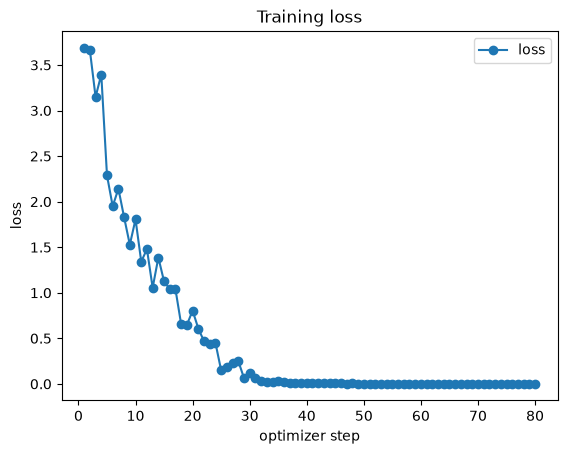

In [69]:
import pandas as pd
import matplotlib.pyplot as plt

loss_rows = [
    {"step": row["step"], "loss": row["loss"]}
    for row in trainer.state.log_history
    if "loss" in row and "step" in row
]

loss_df = pd.DataFrame(loss_rows)
display(loss_df.tail(20))

if len(loss_df) > 0:
    ax = loss_df.plot(x="step", y="loss", marker="o", title="Training loss")
    ax.set_xlabel("optimizer step")
    ax.set_ylabel("loss")
    plt.show()


## 11. After 응답 비교


In [70]:
print("=" * 60)
print("Before vs After 비교")
print("=" * 60)

for index, item in enumerate(test_questions):
    prompt = make_interview_prompt(item)
    after_ans = ask(prompt, max_new_tokens=80, do_sample=False)

    print(f"\n직무: {item['직무']}")
    print(f"경험: {item['경험']}")
    print(f"[Before] {before_answers[index]}")
    print(f"[After ] {after_ans}")
    print("-" * 50)


Before vs After 비교

직무: RAG 개발자
경험: 사내 문서 QA에서 BM25와 dense retrieval을 결합했다. 검색 결과의 관련성은 높지만 최종 답변의 사실성이 낮고, reranker를 넣으면 응답 지연이 증가한다.
[Before] **번호:** 1  
**해설:** 이 질문은 RAG(Retrieval-Augmented Generation) 개발자가 사용하는 BM24와 dense retriever를 결합한 시나리오에서 발생하는 문제점인 "최종 답변 사실성 저하"를 심화적으로 분석하기 위한 기술 면접 질문입니다.  
**질문:** "BM25과 dense retrieval를 결郃하여 검색된 내용의 관련성을 놐�지만, 최종 답변의 사실성은 낮아졌습니다. 이에 대해 어떻게 해결할 수 있을까요?"
[After ] BM25 외에 어떤 질의 유형에 특히 dense retrieval이 적합한 ask인지를 설명해보세요?
--------------------------------------------------


## 12. 어댑터 저장

QLoRA에서는 전체 모델이 아니라 LoRA adapter만 저장합니다.


In [71]:
ADAPTER_DIR = "./lora_adapters/sample_qlora"
model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
print(f"LoRA 어댑터 저장 완료: {ADAPTER_DIR}")


LoRA 어댑터 저장 완료: ./lora_adapters/sample_qlora


## 13. 문제가 계속될 때 보는 체크리스트

- `LoRA params > 0`인데 `Trainable LoRA params = 0`이면 `ensure_lora_trainable()` 셀을 확인하세요.
- `decoded labels`에 질문이 많이 보이면 `train_dataset = full_dataset.select_columns(["prompt", "completion"])`와 `completion_only_loss=True`를 확인하세요.
- 40개 데이터에서는 loss가 step마다 출렁입니다. 10 step 안팎으로 판단하지 말고 80~160 step 추세를 보세요.
- LoRA 설정 셀을 중복 실행하면 adapter가 꼬일 수 있습니다. 이상하면 커널 재시작 후 위에서부터 다시 실행하세요.
- 모델 ID를 바꿨는데 `target_modules` 에러가 나면 `target_modules="all-linear"`로 바꿔 시도하세요.


In [72]:
from datasets import Dataset

# datas/ai_interview_sft.jsonl을 읽은 raw_data 사용
lora_raw_dataset = Dataset.from_list(raw_data)

# 후보 질문 3개 중 경험과 가장 관련된 Top-1 선택
lora_selected_dataset = lora_raw_dataset.map(
    select_most_experience_related
)

# prompt / completion 형식으로 변환
lora_full_dataset = lora_selected_dataset.map(
    format_interview_example
)

lora_train_dataset = lora_full_dataset.select_columns(
    ["prompt", "completion"]
)

print(lora_train_dataset)
print(lora_train_dataset[0]["completion"])

Map:   0%|          | 0/31 [00:00<?, ? examples/s]

Map:   0%|          | 0/31 [00:00<?, ? examples/s]

Dataset({
    features: ['prompt', 'completion'],
    num_rows: 31
})
Qdrant를 선택한 이유를 FAISS와 비교하여 설명해보세요.
